## 动机

In [1]:
import scanpy as sc
import cafe

INFO                                                                                                                                                                                                    
             ██████╗ █████╗ ███████╗███████╗                                                                                                                                                            
           ██╔════╝██╔══██╗██╔════╝██╔════╝                                                                                                                                                             
           ██║     ███████║█████╗  █████╗                                                                                                                                                               
           ██║     ██╔══██║██╔══╝  ██╔══╝                                                                                                                                                           

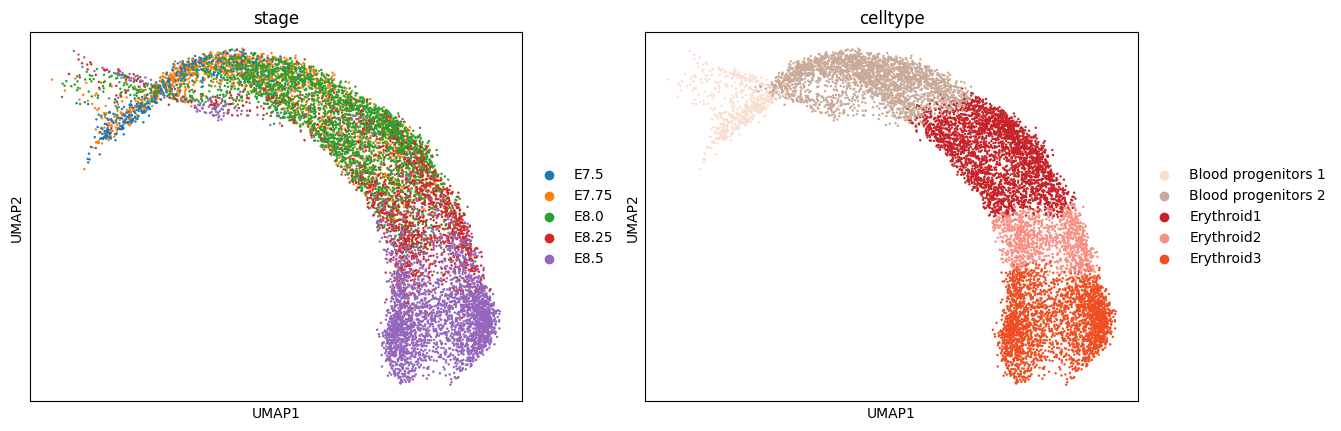

cluster,Blood progenitors 1,Blood progenitors 2,Erythroid1,Erythroid2,Erythroid3
pseudotime,,,,,
E7.5,0.426752,0.569002,0.004246,0.000000,0.000000
E7.75,0.094792,0.550029,0.340550,0.014628,0.000000
E8.0,0.038776,0.349698,0.549271,0.060121,0.002134
E8.25,0.020059,0.092035,0.429499,0.356932,0.101475
E8.5,0.012248,0.028798,0.024164,0.101291,0.833499


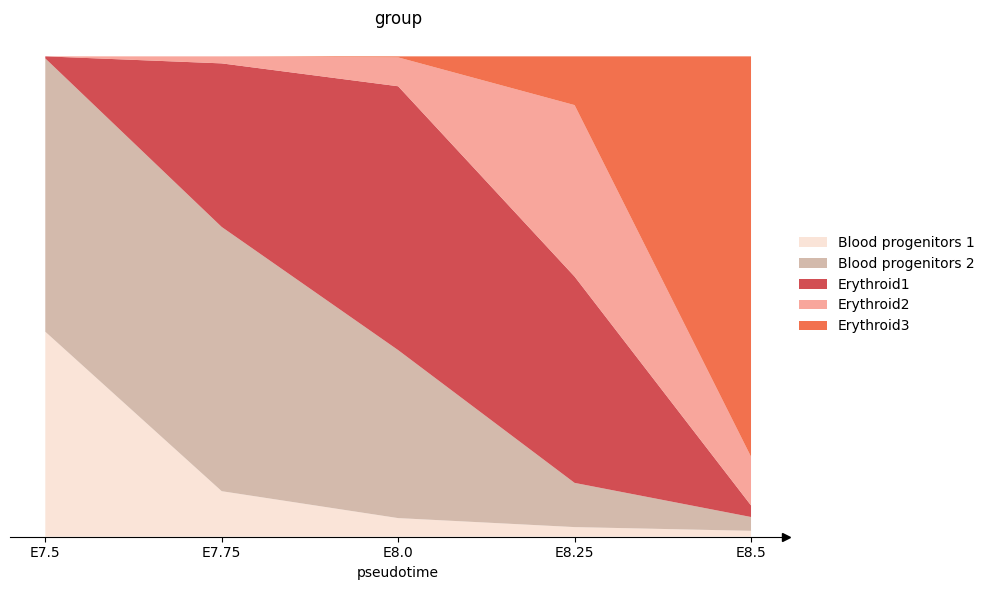

In [3]:
# adata = sc.read("/root/PyCode/scRNA/data/Gastrulation/gastrulation.h5ad") # 原肠胚发育的图谱数据集
# sc.pp.subsample(adata, n_obs=5000)
# fadata = cafe.data.FateAnnData.from_anndata(adata)

# read data
# fadata = cafe.data.read_erythroid_lineage()
time_key = "stage"
cluster_key = "celltype"

# 挑选特征最明显的时间点E7.5之后
adata = sc.read("/root/PyCode/scRNA/data/Gastrulation/erythroid_lineage.h5ad") # 原肠胚发育的图谱数据集
adata = adata[adata.obs["stage"].apply(lambda x: x >= "E7.5")]
fadata = cafe.data.FateAnnData.from_anndata(adata)

# visualization
sc.pl.umap(fadata, color=[time_key, cluster_key])
density_proportions_df = cafe.plot.plot_stack(fadata, pseudotime_key=time_key, cluster=cluster_key, return_proportions=True)

density_proportions_df

数据: 有聚类标签、多个时间点的标签。图中分别展示了降维图、细胞比例随着时间变化的情况。

现象：其实可以根据结合时间先后、降维图和细胞比例趋势确定分化的树结构，在降维空间上细胞连续, 细胞比例变化有早期细胞逐渐比例变少、晚期细胞比例变多的趋势，反映出了血红细胞分化的趋势。

方向：
- （1）根据降维空间临近性，细胞比例变化图简化构建出树结构。如果A类细胞和B类细胞在降维空间上临近，且A/B的比例随时间递减，则有A->B的分化关系。
- （2）TimeWrapper: 跨时间批次的转移概率，实现Moscot，WaddingtonOT的封装的效果,


# 基于 kNN 邻接 + A/B 比例递减 的分化推断

- 相邻准入：用 kNN 图统计跨聚类边，确定“相邻”聚类对；邻接仅作阈值筛选，不参与评分。
- 方向判定：在所有时间点上计算 A/B 比例序列，并用线性回归斜率；仅当斜率 < 0（整体递减）保留 A→B。
- 去环策略：对每个无序聚类对，只保留总分更高的方向，避免互逆环。
- 时间排序：优先使用 `stage` 的分类顺序，否则按首次出现顺序，确保拟合按真实时间推进。

下方代码实现 `DifferentiationTreeInference` 以及最小示例：邻接矩阵、得分前几名的边、链式路径与 UMAP 上的可视化。

In [5]:
import numpy as np
import pandas as pd
from scipy.stats import spearmanr
import networkx as nx
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.neighbors import kneighbors_graph

class DifferentiationTreeInference:
    """相邻准入 + 比例斜率评分 + 去互逆环"""
    
    def __init__(
        self,
        adata,
        cluster_key: str = "celltype",
        time_key: str = "timepoint", 
        basis: str = "X_umap",
        n_neighbors: int = 15,
    ):
        self.adata = adata
        self.cluster_key = cluster_key
        self.time_key = time_key
        self.basis = basis
        self.n_neighbors = n_neighbors
        
        self.clusters = list(adata.obs[cluster_key].cat.categories)
        self.timepoints = self._get_time_order()
        
        self._build_knn_graph()
        
    def _get_time_order(self):
        obs_time = self.adata.obs[self.time_key]
        if pd.api.types.is_categorical_dtype(obs_time):
            return list(obs_time.cat.categories)
        return list(pd.unique(obs_time))  # 保留出现顺序
        
    def _build_knn_graph(self):
        coords = self.adata.obsm[self.basis]
        self.knn_graph = kneighbors_graph(
            coords, 
            n_neighbors=self.n_neighbors, 
            mode='connectivity',
            include_self=False
        )
        print(f"构建 kNN 图完成: {self.knn_graph.shape[0]} 细胞, k={self.n_neighbors}")
    
    # ========== 1) 基于 kNN 的空间邻接（仅用于准入） ==========
    def compute_cluster_adjacency(self) -> pd.DataFrame:
        clusters = self.adata.obs[self.cluster_key].values
        n_clusters = len(self.clusters)
        adjacency_counts = np.zeros((n_clusters, n_clusters))
        cluster_to_idx = {c: i for i, c in enumerate(self.clusters)}
        knn_coo = self.knn_graph.tocoo()
        for i, j in zip(knn_coo.row, knn_coo.col):
            ci, cj = clusters[i], clusters[j]
            if ci != cj:
                idx_i, idx_j = cluster_to_idx[ci], cluster_to_idx[cj]
                adjacency_counts[idx_i, idx_j] += 1
        cluster_sizes = self.adata.obs[self.cluster_key].value_counts()
        for i, ci in enumerate(self.clusters):
            if cluster_sizes[ci] > 0:
                adjacency_counts[i, :] /= cluster_sizes[ci]
        adj_df = pd.DataFrame(adjacency_counts, index=self.clusters, columns=self.clusters)
        adj_df = (adj_df + adj_df.T) / 2  # 对称化
        return adj_df
    
    def get_adjacent_clusters(self, threshold: float = 0.05) -> dict:
        adj_df = self.compute_cluster_adjacency()
        neighbors = {}
        for cluster in self.clusters:
            adj_scores = adj_df.loc[cluster].drop(cluster)
            significant = adj_scores[adj_scores > threshold].sort_values(ascending=False)
            neighbors[cluster] = significant.index.tolist()
        return neighbors
    
    # ========== 2) 时间动态 ==========
    def compute_temporal_dynamics(self) -> pd.DataFrame:
        counts = self.adata.obs.groupby([self.time_key, self.cluster_key], sort=False).size().unstack(fill_value=0)
        counts = counts.reindex(self.timepoints)  # 按设定的时间顺序
        return counts.div(counts.sum(axis=1), axis=0)
    
    def compute_temporal_trend(self) -> pd.DataFrame:
        proportions = self.compute_temporal_dynamics()
        time_numeric = np.arange(len(self.timepoints))
        trends = []
        for cluster in self.clusters:
            if cluster in proportions.columns:
                y = proportions.loc[self.timepoints, cluster].values
                corr, pval = spearmanr(time_numeric, y)
                slope = np.polyfit(time_numeric, y, 1)[0]
                trends.append({
                    "cluster": cluster,
                    "slope": slope,
                    "correlation": corr,
                    "pvalue": pval,
                    "direction": "increasing" if slope > 0 else "decreasing"
                })
        return pd.DataFrame(trends)
    
    # ========== 3) 相对比例 A/B 递减（评分仅用比例，可选流量），相邻仅作准入 ==========
    def compute_edge_scores(
        self,
        adjacency_threshold: float = 0.02,
        ratio_weight: float = 1.0,
        flow_weight: float = 0.0,  # 默认不启用流量项
        eps: float = 1e-6,
    ) -> pd.DataFrame:
        """若 A、B 相邻（通过阈值），且 A/B 随时间递减，则建 A→B；总分只看比例(及可选流量)。"""
        adj_df = self.compute_cluster_adjacency()
        proportions = self.compute_temporal_dynamics()
        time_numeric = np.arange(len(self.timepoints))
        raw_edges = []
        for source in self.clusters:
            for target in self.clusters:
                if source == target:
                    continue
                adj_score = adj_df.loc[source, target]
                if adj_score < adjacency_threshold:
                    continue  # kNN 仅作准入
                if source not in proportions.columns or target not in proportions.columns:
                    continue
                ratio = proportions.loc[self.timepoints, source].values / (proportions.loc[self.timepoints, target].values + eps)
                slope_ratio = np.polyfit(time_numeric, ratio, 1)[0]
                if slope_ratio >= 0:
                    continue  # 只有 A/B 递减才建边
                ratio_score = -slope_ratio  # 递减越快得分越高
                flow_score = self._compute_flow_score(source, target, proportions) if flow_weight > 0 else 0.0
                total = (
                    ratio_weight * ratio_score +
                    flow_weight * flow_score
                )
                raw_edges.append({
                    "source": source,
                    "target": target,
                    "adjacency_score": adj_score,
                    "ratio_slope": slope_ratio,
                    "ratio_score": ratio_score,
                    "flow_score": flow_score,
                    "total_score": total,
                })
        if not raw_edges:
            print("警告：没有找到符合条件的边，请检查参数设置")
            return pd.DataFrame()
        # 去掉互逆环：对无序对只保留总分最高的方向
        df = pd.DataFrame(raw_edges).sort_values("total_score", ascending=False)
        df["pair"] = df.apply(lambda r: tuple(sorted([r["source"], r["target"]])), axis=1)
        df = df.drop_duplicates(subset="pair", keep="first").drop(columns="pair")
        return df.reset_index(drop=True)
    
    def _compute_flow_score(self, source: str, target: str, proportions: pd.DataFrame) -> float:
        if source not in proportions.columns or target not in proportions.columns:
            return 0.0
        source_delta = np.diff(proportions.loc[self.timepoints, source].values)
        target_delta = np.diff(proportions.loc[self.timepoints, target].values)
        if len(source_delta) < 2:
            return 0.0
        corr, _ = spearmanr(source_delta, target_delta)
        return -corr if not np.isnan(corr) else 0.0
    
    # ========== 4) 构建链式结构 ==========
    def build_lineage_chains(
        self,
        score_threshold: float = 0.05,
    ) -> list:
        edge_df = self.compute_edge_scores()
        if edge_df.empty:
            return []
        edge_df = edge_df[edge_df["total_score"] > score_threshold]
        G = nx.DiGraph()
        G.add_nodes_from(self.clusters)
        for _, row in edge_df.iterrows():
            G.add_edge(row["source"], row["target"], weight=row["total_score"])
        roots = [n for n in G.nodes() if G.in_degree(n) == 0 and G.out_degree(n) > 0]
        terminals = [n for n in G.nodes() if G.out_degree(n) == 0 and G.in_degree(n) > 0]
        print(f"识别到 {len(roots)} 个根节点: {roots}")
        print(f"识别到 {len(terminals)} 个终末节点: {terminals}")
        chains = []
        for root in roots:
            for terminal in terminals:
                try:
                    for path in nx.all_simple_paths(G, root, terminal):
                        chains.append(path)
                except nx.NetworkXNoPath:
                    continue
        return chains
    
    def build_differentiation_tree(self, score_threshold: float = 0.05) -> nx.DiGraph:
        edge_df = self.compute_edge_scores()
        if edge_df.empty:
            return nx.DiGraph()
        edge_df = edge_df[edge_df["total_score"] > score_threshold]
        G = nx.DiGraph()
        G.add_nodes_from(self.clusters)
        for target in self.clusters:
            incoming = edge_df[edge_df["target"] == target]
            if not incoming.empty:
                best = incoming.nlargest(1, "total_score").iloc[0]
                G.add_edge(
                    best["source"],
                    best["target"],
                    weight=best["total_score"],
                    adjacency=best.get("adjacency_score", 0.0),
                    ratio_score=best["ratio_score"],
                    flow=best.get("flow_score", 0.0),
                )
        return G

print("DifferentiationTreeInference 类已定义（相邻准入 + 比例评分，无互逆环）")
print("关键要点:")
print("  1. kNN 仅作准入，不参与总分")
print("  2. 总分只看比例斜率(可选流量)")
print("  3. 对互逆对只保留高分方向，避免环")

DifferentiationTreeInference 类已定义（相邻准入 + 比例评分，无互逆环）
关键要点:
  1. kNN 仅作准入，不参与总分
  2. 总分只看比例斜率(可选流量)
  3. 对互逆对只保留高分方向，避免环


In [6]:
# 测试推断器
infer = DifferentiationTreeInference(
    fadata,
    cluster_key="celltype",
    time_key="stage",
    basis="X_umap",
    n_neighbors=15
)

# 1. 查看聚类邻接矩阵
adj_df = infer.compute_cluster_adjacency()
print("聚类邻接矩阵（基于 kNN 图的跨聚类边统计）：")
adj_df

构建 kNN 图完成: 9707 细胞, k=15
聚类邻接矩阵（基于 kNN 图的跨聚类边统计）：
聚类邻接矩阵（基于 kNN 图的跨聚类边统计）：


,Blood progenitors 1,Blood progenitors 2,Erythroid1,Erythroid2,Erythroid3
Blood progenitors 1,0.000000,0.538828,0.000000,0.000000,0.000000
Blood progenitors 2,0.538828,0.000000,0.375164,0.000000,0.000000
Erythroid1,0.000000,0.375164,0.000000,0.464383,0.000000
Erythroid2,0.000000,0.000000,0.464383,0.000000,0.386122
Erythroid3,0.000000,0.000000,0.000000,0.386122,0.000000


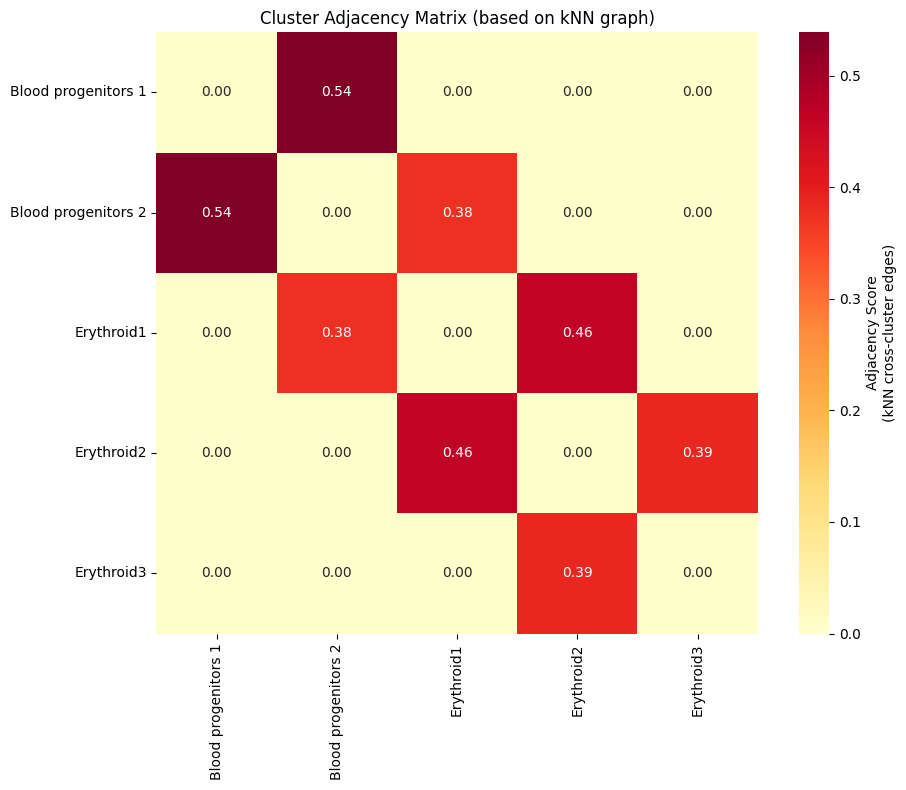


每个聚类的主要相邻聚类:
  Blood progenitors 1: ['Blood progenitors 2']
  Blood progenitors 2: ['Blood progenitors 1', 'Erythroid1']
  Erythroid1: ['Erythroid2', 'Blood progenitors 2']
  Erythroid2: ['Erythroid1', 'Erythroid3']
  Erythroid3: ['Erythroid2']
  Blood progenitors 1: ['Blood progenitors 2']
  Blood progenitors 2: ['Blood progenitors 1', 'Erythroid1']
  Erythroid1: ['Erythroid2', 'Blood progenitors 2']
  Erythroid2: ['Erythroid1', 'Erythroid3']
  Erythroid3: ['Erythroid2']


In [7]:
# 2. 可视化邻接矩阵热力图
fig, ax = plt.subplots(figsize=(10, 8))
sns.heatmap(
    adj_df, 
    cmap="YlOrRd", 
    annot=True, 
    fmt=".2f",
    square=True,
    ax=ax,
    cbar_kws={"label": "Adjacency Score\n(kNN cross-cluster edges)"}
)
ax.set_title("Cluster Adjacency Matrix (based on kNN graph)")
plt.tight_layout()
plt.show()

# 对比：哪些聚类对是真正"相邻"的
print("\n每个聚类的主要相邻聚类:")
for cluster, neighbors in infer.get_adjacent_clusters(threshold=0.05).items():
    if neighbors:
        print(f"  {cluster}: {neighbors[:3]}")

In [8]:
# 3. 计算边得分并构建链式轨迹
edge_df = infer.compute_edge_scores(adjacency_threshold=0.02)
print(f"符合条件的边数量: {len(edge_df)}")
print("\n得分最高的边:")
edge_df.head(15)

符合条件的边数量: 4

得分最高的边:


,source,target,adjacency_score,ratio_slope,ratio_score,flow_score,total_score
0,Erythroid2,Erythroid3,0.386122,-1462.467723,1462.467723,0.0,1462.467723
1,Erythroid1,Erythroid2,0.464383,-851.416699,851.416699,0.0,851.416699
2,Blood progenitors 2,Erythroid1,0.375164,-26.695427,26.695427,0.0,26.695427
3,Blood progenitors 1,Blood progenitors 2,0.538828,-0.060385,0.060385,0.0,0.060385


In [9]:
# 4. 构建分化链
chains = infer.build_lineage_chains(score_threshold=0.05)
print(f"\n发现 {len(chains)} 条分化链:")
for i, chain in enumerate(chains):
    print(f"  链 {i+1}: {' → '.join(chain)}")

识别到 1 个根节点: ['Blood progenitors 1']
识别到 1 个终末节点: ['Erythroid3']

发现 1 条分化链:
  链 1: Blood progenitors 1 → Blood progenitors 2 → Erythroid1 → Erythroid2 → Erythroid3


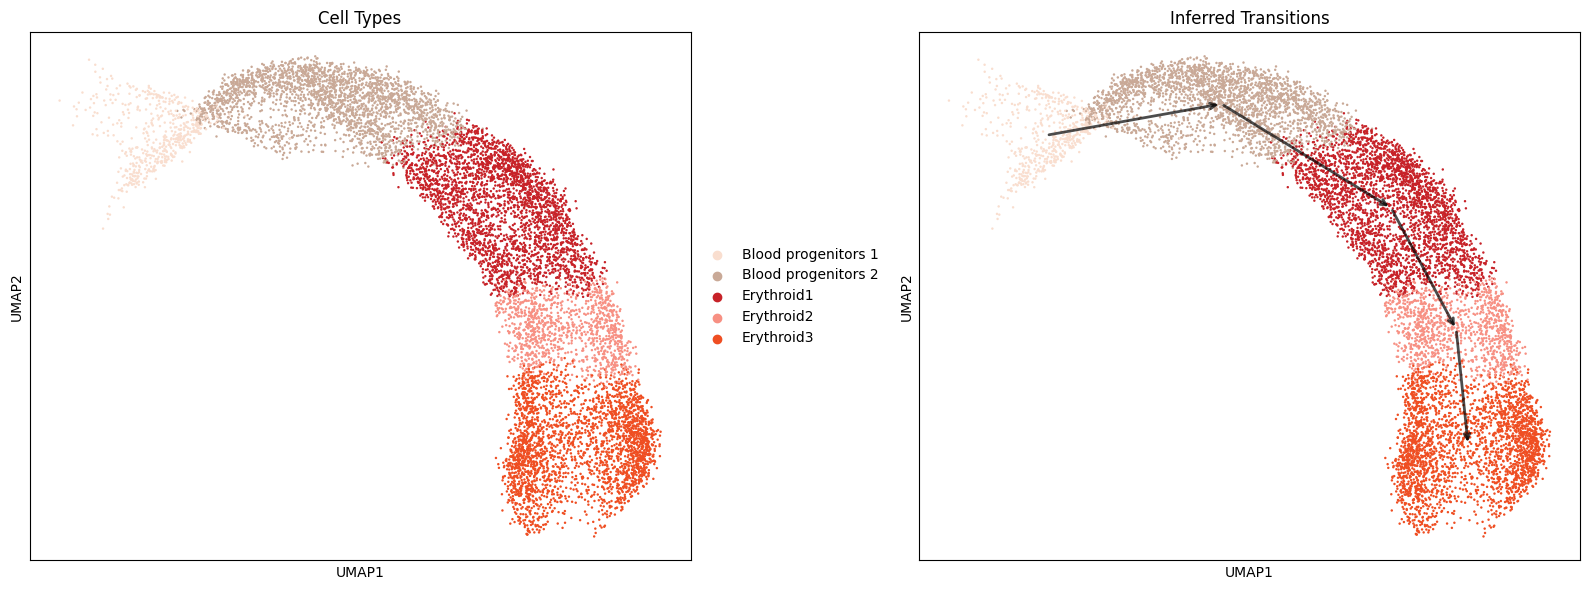

In [10]:
# 5. 可视化：在 UMAP 上显示推断的链式轨迹
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# 左图：原始 UMAP + 聚类
sc.pl.umap(fadata, color="celltype", ax=axes[0], show=False, title="Cell Types")

# 右图：UMAP + 推断的边
sc.pl.umap(fadata, color="celltype", ax=axes[1], show=False, title="Inferred Transitions", legend_loc=None)

# 计算聚类中心用于绘制边
coords = fadata.obsm["X_umap"]
clusters = fadata.obs["celltype"]
centroids = {}
for c in infer.clusters:
    mask = clusters == c
    centroids[c] = coords[mask].mean(axis=0)

# 绘制推断的边
G = infer.build_differentiation_tree(score_threshold=0.05)
for source, target in G.edges():
    if source in centroids and target in centroids:
        x = [centroids[source][0], centroids[target][0]]
        y = [centroids[source][1], centroids[target][1]]
        axes[1].annotate(
            "", 
            xy=(x[1], y[1]), 
            xytext=(x[0], y[0]),
            arrowprops=dict(arrowstyle="->", color="black", lw=2, alpha=0.7)
        )

plt.tight_layout()
plt.show()

## 扩展：TimeWrapper - 整合 WaddingtonOT/Moscot 结果

上述方法主要依赖降维空间的几何邻接和比例变化。为了利用更精细的时间序列信息，我们可以引入 **最优传输 (Optimal Transport)** 方法（如 WaddingtonOT, Moscot）。

这些工具通常输出**细胞级**的转移概率矩阵（$T_{t, t+1}$）。`TimeWrapper` 的作用是将这些微观的细胞转移概率聚合为宏观的**聚类级**转移流，从而直接量化 Cluster A $\to$ Cluster B 的分化强度。

**核心逻辑：**
$$ \text{Flow}(A \to B) = \sum_{i \in A, j \in B} T_{i,j} $$
其中 $T_{i,j}$ 是从时间点 $t$ 的细胞 $i$ 到时间点 $t+1$ 的细胞 $j$ 的转移概率（或质量）。

> 参考：https://moscot.readthedocs.io/en/latest/notebooks/tutorials/200_temporal_problem.html

In [11]:
from scipy import sparse

class TimeWrapper:
    """
    封装时间序列分析结果（如 WaddingtonOT, Moscot）。
    将细胞级的转移概率矩阵（Tmaps）聚合为聚类级的转移流。
    """
    def __init__(self, adata, time_key="stage", cluster_key="celltype"):
        self.adata = adata
        self.time_key = time_key
        self.cluster_key = cluster_key
        self.clusters = list(adata.obs[cluster_key].cat.categories)
        
    def compute_cluster_transitions(self, tmaps: dict, normalize: bool = True) -> pd.DataFrame:
        """
        将时间点间的 Tmaps 聚合为全局的聚类转移矩阵。
        
        Args:
            tmaps: 字典，键为 (t_start, t_end)，值为稀疏矩阵或数组 (n_cells_t_start x n_cells_t_end)
                   表示从 t_start 时刻细胞到 t_end 时刻细胞的转移概率/质量。
            normalize: 是否对结果按行归一化（转换为转移概率）。
                   
        Returns:
            pd.DataFrame: 行列均为 clusters 的转移矩阵。
        """
        cluster_flow = pd.DataFrame(0.0, index=self.clusters, columns=self.clusters)
        obs = self.adata.obs
        
        print(f"开始聚合 {len(tmaps)} 个时间对的转移矩阵...")
        
        for (t1, t2), tmap in tmaps.items():
            # 1. 获取对应时间点的细胞索引
            cells_t1_mask = (obs[self.time_key] == t1).values
            cells_t2_mask = (obs[self.time_key] == t2).values
            
            if not np.any(cells_t1_mask) or not np.any(cells_t2_mask):
                continue
                
            # 2. 校验维度
            n_c1 = np.sum(cells_t1_mask)
            n_c2 = np.sum(cells_t2_mask)
            if tmap.shape != (n_c1, n_c2):
                print(f"  [跳过] {t1}->{t2}: Tmap维度 {tmap.shape} 与元数据 ({n_c1}, {n_c2}) 不匹配")
                continue
            
            # 3. 获取这些细胞的聚类标签
            clusters_t1 = obs.loc[cells_t1_mask, self.cluster_key].values
            clusters_t2 = obs.loc[cells_t2_mask, self.cluster_key].values
            
            # 4. 聚合：遍历聚类对 (Source -> Target)
            # 优化：对于稀疏矩阵，可以先转为 COO 或 CSR 进行块切片
            if sparse.issparse(tmap):
                tmap = tmap.tocsr()
                
            for i, source_cluster in enumerate(self.clusters):
                # 找到 t1 时刻属于 source_cluster 的细胞在 tmap 中的行索引
                # 注意：tmap 的行是相对于 t1 时刻细胞子集的，不是全局索引
                # clusters_t1 已经是 t1 子集的标签了，所以直接用 np.where 即可
                row_indices = np.where(clusters_t1 == source_cluster)[0]
                if len(row_indices) == 0:
                    continue
                
                # 提取这些行的子矩阵
                sub_matrix = tmap[row_indices, :]
                
                for j, target_cluster in enumerate(self.clusters):
                    col_indices = np.where(clusters_t2 == target_cluster)[0]
                    if len(col_indices) == 0:
                        continue
                    
                    # 计算流向 target_cluster 的总质量
                    mass = sub_matrix[:, col_indices].sum()
                    cluster_flow.loc[source_cluster, target_cluster] += mass
        
        if normalize:
            # 按行归一化：每个 Source Cluster 流出的总概率为 1
            row_sums = cluster_flow.sum(axis=1)
            cluster_flow = cluster_flow.div(row_sums + 1e-6, axis=0)
            
        return cluster_flow

print("TimeWrapper 类已定义。")

TimeWrapper 类已定义。


开始聚合 4 个时间对的转移矩阵...

基于模拟 Tmaps 的聚类转移矩阵 (前 5 行/列):


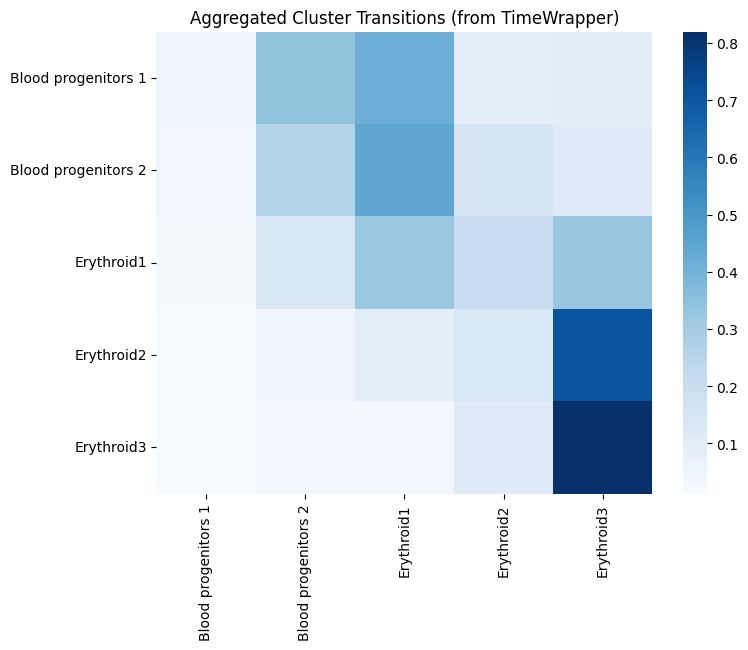

In [12]:
# TimeWrapper 使用示例（模拟数据）

# 1. 初始化
time_wrapper = TimeWrapper(fadata, time_key="stage", cluster_key="celltype")

# 2. 模拟 WaddingtonOT/Moscot 的输出
# 假设我们有两个时间对：E7.5 -> E8.0 和 E8.0 -> E8.5
# 这里随机生成稀疏矩阵作为 Tmap
import scipy.sparse
tmaps_mock = {}
timepoints = infer.timepoints # 使用之前推断器获取的时间点顺序

for i in range(len(timepoints) - 1):
    t1, t2 = timepoints[i], timepoints[i+1]
    n1 = (fadata.obs["stage"] == t1).sum()
    n2 = (fadata.obs["stage"] == t2).sum()
    
    if n1 > 0 and n2 > 0:
        # 生成随机稀疏矩阵 (密度 0.1)
        random_tmap = scipy.sparse.random(n1, n2, density=0.1, format='csr')
        tmaps_mock[(t1, t2)] = random_tmap

# 3. 计算聚类转移矩阵
cluster_transitions = time_wrapper.compute_cluster_transitions(tmaps_mock, normalize=True)

print("\n基于模拟 Tmaps 的聚类转移矩阵 (前 5 行/列):")
cluster_transitions.iloc[:5, :5]

# 4. 可视化转移矩阵
plt.figure(figsize=(8, 6))
sns.heatmap(cluster_transitions, cmap="Blues", annot=False)
plt.title("Aggregated Cluster Transitions (from TimeWrapper)")
plt.show()